# 045 视觉输入与增强设计

真实重算坐标变换、精确账本与12次训练。标签和背景计划由公开生成器固定；不要把旧输出当作本轮执行。

In [1]:
from pathlib import Path
import os,sys,json,hashlib,gzip,tempfile
ROOT=next((p.resolve() for p in [Path.cwd(),Path.cwd()/'units'/'045'] if (p/'experiment.py').is_file() and (p/'data/images.json').is_file()),None)
if ROOT is None:raise RuntimeError('请从045目录或课程根启动')
os.environ.setdefault('MPLCONFIGDIR',str(ROOT/'../../tmp/045-nb-mpl'))
os.environ.setdefault('XDG_CACHE_HOME',str(ROOT/'../../tmp/045-nb-cache'))
sys.path.insert(0,str(ROOT))
expected={'experiment.py': 'a96e908cf46ed9c65bc833626b551c1606bbec4cc9b71469a1899febf2b48c93', 'test_experiment.py': '6cde5575a4f322c5a5fd1b902dbd49294c6e0317a15a9f761e9aa5123ea954ae', 'generate_data.py': 'a70506d4f84d2c13e76caec2c947ed9d8132eec8f1dac9c5322b374f2d43ec22', 'make_figures.py': 'a05c5cc4e49bce9c0f3c1e3935ce8384f3726af894fb212c2692546540515d11', 'data/images.json': 'b69d30e95c4ede4f041fdda756d271c5b9e0cd9e0a3b268505b731cbcefc03b7', 'data/augmentation_plans.json': '033b5efc563414469bbf7e5f7c24cbbf194693698fa017d1e0d27febcd2063be', 'data/data_manifest.json': 'f1ee8b01013ce907ffbef0d0b8784c42f2694026415ecdda98c357358e89780b', 'outputs/results.json': '1455333df2163bad7723529cd8d5e57cee3d8591cf8ce8c76c8636404f1b6b8c', 'outputs/training_traces.json.gz': '7f6bc8343d9c33b33af6f19fced4ef0362b653b045f29d7f4375f3ef342671e7', 'figures/01_channels.png': '7a19330eb8bed49402d993f7d7c3391edc35230382eee61e1c9649c789e640b4', 'figures/02_geometry.png': '73492e77d95be70cfcea957501c1799dd5f5acb7adfb29ed7a52f170b3d1bcf1', 'figures/03_mask_interpolation.png': '09cf9466882bc5d350b8eff90010ee31cc241f83a5eecd76c6260a67edbfd4eb', 'figures/04_half_pixel.png': '05b5436e105e6d0256185397b4c50facafceeccf494c8dd0455255da021e7a75', 'figures/05_hand_transform.png': '94ab57f245141928699bbc5fae85d041163654b8dbb7ee4edad05a87ab9f1d9d', 'figures/06_hand_gradient.png': '8067c4b33da2caf847524d4173f8c592063bfe0adf22fe10a9a243f20c079a0c', 'figures/07_background_views.png': '52539f176595ca46ad7fe6335924fcd17d28328957dda63dcfb0535fcad4f9ea', 'figures/08_replay.png': '8222ad6a5ddcd1cd78c108b1273945a1e8db7e6e4dc9cc5783a884bdd5ed773c', 'figures/09_ablation.png': '526e7dfde82dbce80975a695f63bcf8984a259035712ce0c22779c14929d2294', 'figures/10_all_traces.png': '3030eff0e9ee4f3a349650dc39b1fc70e9815123fcb5776e24d1f174dcc7d6c1', 'figures/11_normalization.png': '227ffb726799e9f4d2117fd3a71e44b51756c1f734501bd8b1c134b73ace1e4d', 'figures/12_antialias.png': 'ea7cfc3c1f7ac0b0d8b7a17eb602be6a925be3892b10dd210b4df83590129354'}
for filename,digest in expected.items():
    if hashlib.sha256((ROOT/filename).read_bytes()).hexdigest()!=digest:raise ValueError('文件版本不一致：'+filename)
import numpy as np,torch
import experiment
print('runtime',sys.version.split()[0],np.__version__,torch.__version__)
print('checked source/data/output/figure files:',len(expected))
from IPython.display import display,Image
from io import BytesIO
import matplotlib.pyplot as plt
def show(fig):
    b=BytesIO();fig.savefig(b,format='png',dpi=130,bbox_inches='tight');display(Image(data=b.getvalue()));plt.close(fig)

runtime 3.12.14 2.3.5 2.7.1+cpu
checked source/data/output/figure files: 21


## 1 同一参数作用于图像、掩码与框
注意像素列索引W-1-q与框边缘W-x不同。裁后消失的框必须同步移除标签。

box: [[1.0, 0.0, 4.0, 2.0]] keep original indices: [0] retention: [0.75, 0.0]


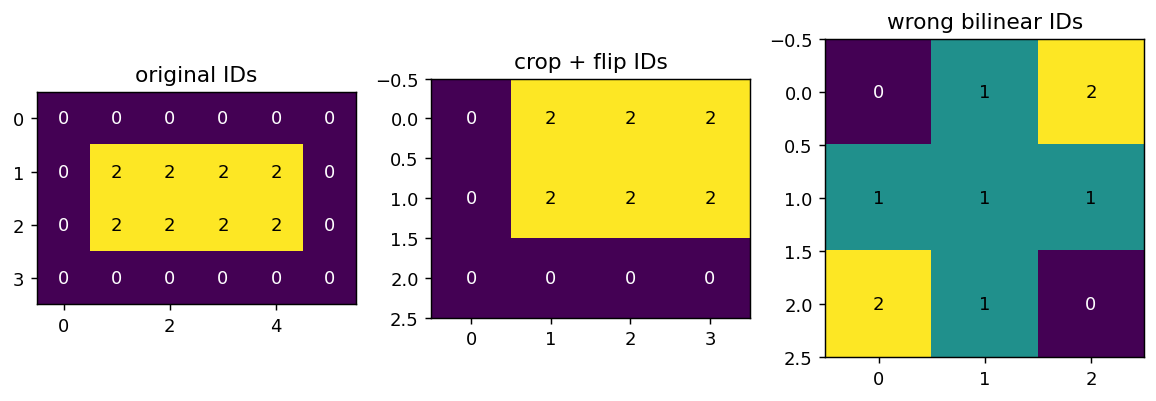

nearest categories: [0 2]


In [2]:
g=experiment.geometry_demo()
print('box:',g['boxes'],'keep original indices:',g['keep_indices'],'retention:',g['box_area_retention'])
fig,axes=plt.subplots(1,3,figsize=(9,3))
for ax,key,title in zip(axes,['original_mask','mask','wrong_bilinear_mask'],['original IDs','crop + flip IDs','wrong bilinear IDs']):
    a=np.array(g[key]);im=ax.imshow(a,vmin=0,vmax=2,cmap='viridis');ax.set_title(title)
    for (r,c),v in np.ndenumerate(a):ax.text(c,r,f'{v:.1g}',ha='center',va='center',color='white' if v<1 else 'black')
fig.tight_layout();show(fig)
print('nearest categories:',np.unique(g['nearest_mask']))

## 2 完整手算链与同步更新
标签是原始空间均值；输入梯度把标签视为固定监督值。

features: [[ 1.  -1.  -0.5  0. ]
 [ 0.   1.  -0.5  0.5]] prediction: [ 2.50000000e-01 -1.38777878e-17] loss: 0.1064453125
gradient: [-0.09375  -0.21875   0.203125 -0.15625  -0.40625 ]
next prediction/loss: [0.28828125 0.08046875] 0.07969512939453126


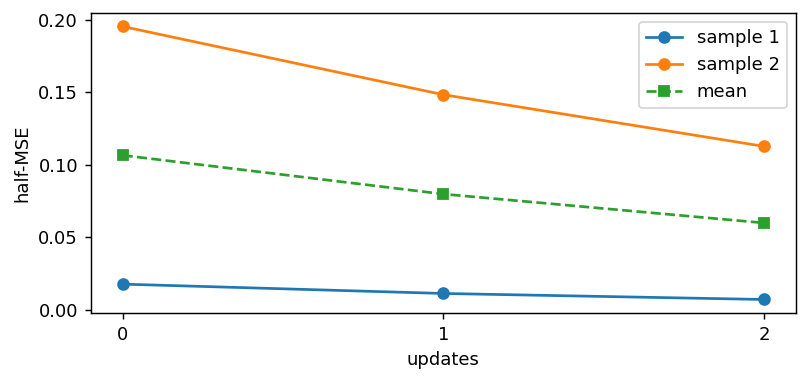

In [3]:
X=np.array([[[[0,1],[.5,.25]]],[[[1,.5],[.75,.25]]]],float);y=np.array([7/16,5/8])
u=(np.flip(X,axis=-1)-.5)/.5;u=u.reshape(2,4)
w=np.array([.2,-.1,.1,.3]);b=0.;prediction=u@w+b;residual=prediction-y;up=residual/2
print('features:',u,'prediction:',prediction,'loss:',np.mean(residual**2)/2)
gw=u.T@up;gb=up.sum();print('gradient:',np.r_[gw,gb])
w1=w-.1*gw;b1=b-.1*gb;p1=u@w1+b1
ledger=experiment.hand_ledger();np.testing.assert_allclose(p1,[s['prediction']['float'] for s in ledger[1]['samples']])
print('next prediction/loss:',p1,np.mean((p1-y)**2)/2)
fig,ax=plt.subplots(figsize=(7,3))
for i in range(2):ax.plot(range(3),[s['samples'][i]['loss']['float'] for s in ledger],'o-',label=f'sample {i+1}')
ax.plot(range(3),[s['loss']['float'] for s in ledger],'s--',label='mean');ax.set(xlabel='updates',ylabel='half-MSE',xticks=[0,1,2]);ax.legend();show(fig)

## 3 取一条真实回放记录
后两臂图像相同；旋转方向标签不同。训练背景替换使用生成器已知mask，这是一项额外信息。

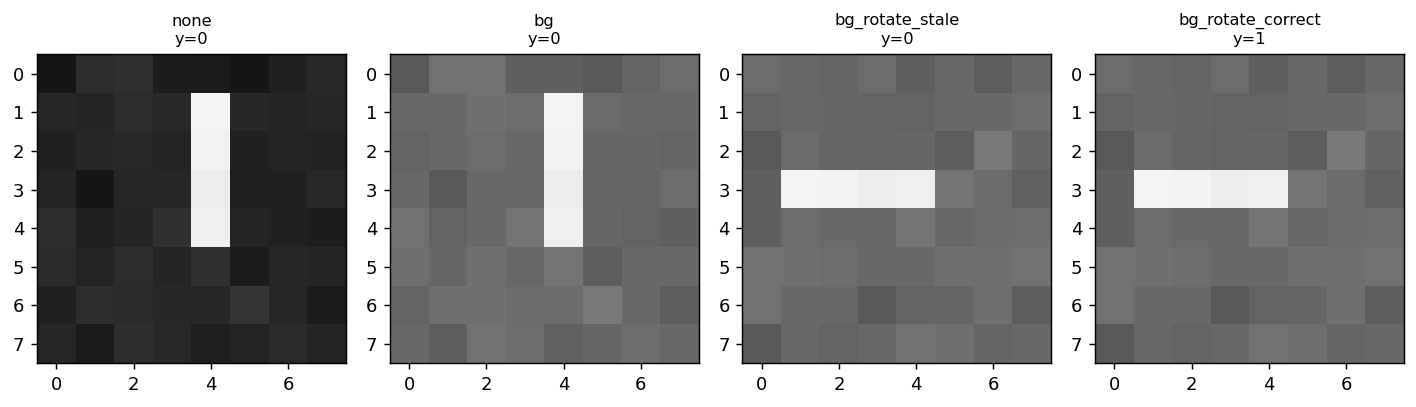

record seed=4511 step=0 index= 2 new background= 0.41452212375326614 rot90= 1
labels changed: 18


In [4]:
data=json.loads((ROOT/'data/images.json').read_text());plans=json.loads((ROOT/'data/augmentation_plans.json').read_text());plan=plans['4511'];i=int(np.flatnonzero(plan['rotate90'][0])[0])
fig,axes=plt.subplots(1,4,figsize=(11,3))
for ax,arm in zip(axes,experiment.ARMS):
    xx,yy=experiment.replay(data['train'],plan,0,arm);ax.imshow(xx[i,0],vmin=0,vmax=1,cmap='gray');ax.set_title(arm.replace('background','bg')+f'\ny={yy[i]}',fontsize=9)
fig.tight_layout();show(fig)
wrong,wy=experiment.replay(data['train'],plan,0,'background_rotate_stale');right,ry=experiment.replay(data['train'],plan,0,'background_rotate_correct')
np.testing.assert_array_equal(wrong,right)
print('record seed=4511 step=0 index=',i,'new background=',plan['background'][0][i],'rot90=',plan['rotate90'][0][i])
print('labels changed:',int(np.sum(wy!=ry)))

## 4 真正重新完成12次训练和全部轨迹
同初始化的四臂固定160步，不搜索、早停或挑种子。新结果写临时目录，不覆写参考件。

In [5]:
with tempfile.TemporaryDirectory() as output:
    fresh=experiment.run(output)
    fresh_trace=json.loads(gzip.decompress((Path(output)/'training_traces.json.gz').read_bytes()))
reference=json.loads((ROOT/'outputs/results.json').read_text())
reference_trace=json.loads(gzip.decompress((ROOT/'outputs/training_traces.json.gz').read_bytes()))
def compare(a,b,path='root'):
    if isinstance(a,dict):
        if a.keys()!=b.keys():raise ValueError('key mismatch '+path)
        for key in a:compare(a[key],b[key],path+'.'+key)
    elif isinstance(a,list):
        if len(a)!=len(b):raise ValueError('length mismatch '+path)
        for i,(x,y) in enumerate(zip(a,b)):compare(x,y,path+f'[{i}]')
    elif isinstance(a,float):np.testing.assert_allclose(a,b,rtol=1e-9,atol=1e-11,err_msg=path)
    elif a!=b:raise ValueError('value mismatch '+path)
for key in ['hand','geometry','learning']:compare(fresh[key],reference[key],key)
# Numeric trace compare avoids claiming cross-platform compressed-byte identity.
if len(fresh_trace)!=len(reference_trace):raise ValueError('trace run count changed')
for a,b in zip(fresh_trace,reference_trace):
    if a['arm']!=b['arm'] or a['seed']!=b['seed']:raise ValueError('trace run identity changed')
    if len(a['states'])!=len(b['states']):raise ValueError('trace state count changed')
    for sa,sb in zip(a['states'],b['states']):
        if len(sa['parameters'])!=len(sb['parameters']):raise ValueError('parameter role count changed')
        for pa,pb in zip(sa['parameters'],sb['parameters']):np.testing.assert_allclose(pa,pb,rtol=1e-9,atol=1e-11)
        if 'augmented_train_nll' in sa:np.testing.assert_allclose(sa['augmented_train_nll'],sb['augmented_train_nll'],rtol=1e-9,atol=1e-11)
print('reran',len(fresh['learning']['runs']),'fits and',fresh['learning']['total_updates'],'updates')
print('gradient reference max error:',fresh['learning']['numpy_reference_max_abs_gap'])

reran 12 fits and 1920 updates
gradient reference max error: 1.942890293094024e-16


## 5 查看全部条件与种子，而不只看最佳准确率
种子平均不是集成，也不等于独立数据重复。

none {'validation_x': {'nll': 0.000234, 'accuracy': 1.0}, 'test_x': {'nll': 0.000226, 'accuracy': 1.0}, 'test_swapped': {'nll': 8.19319, 'accuracy': 0.0}, 'test_neutral': {'nll': 0.65142, 'accuracy': 0.552083}}
background {'validation_x': {'nll': 0.045076, 'accuracy': 1.0}, 'test_x': {'nll': 0.043014, 'accuracy': 1.0}, 'test_swapped': {'nll': 0.068265, 'accuracy': 1.0}, 'test_neutral': {'nll': 0.001291, 'accuracy': 1.0}}
background_rotate_stale {'validation_x': {'nll': 0.619774, 'accuracy': 0.583333}, 'test_x': {'nll': 0.630811, 'accuracy': 0.638021}, 'test_swapped': {'nll': 0.587661, 'accuracy': 0.6875}, 'test_neutral': {'nll': 0.536284, 'accuracy': 0.721354}}
background_rotate_correct {'validation_x': {'nll': 0.041377, 'accuracy': 1.0}, 'test_x': {'nll': 0.040019, 'accuracy': 1.0}, 'test_swapped': {'nll': 0.079245, 'accuracy': 1.0}, 'test_neutral': {'nll': 0.001914, 'accuracy': 1.0}}


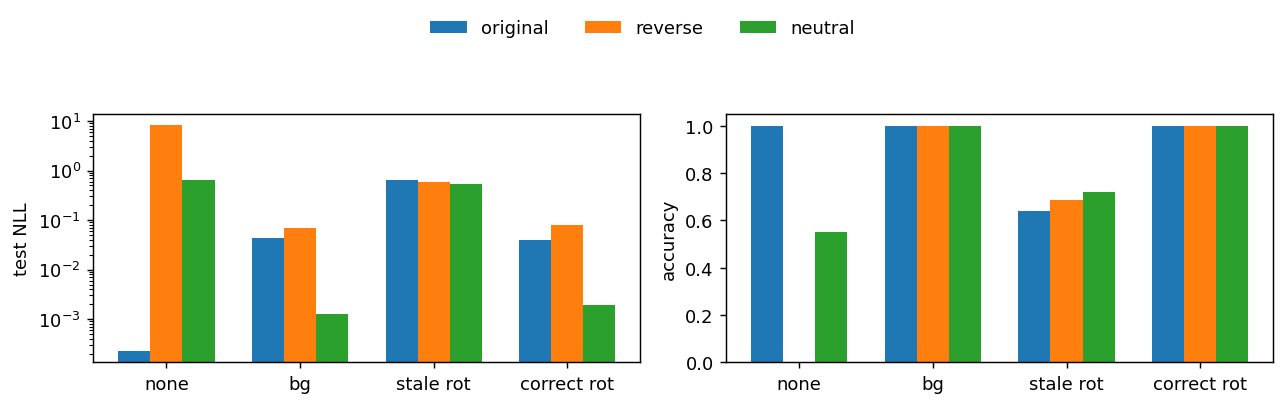

全部参数状态: 1932


In [6]:
summary=fresh['learning']['summary']
for arm,views in summary.items():
    print(arm,{view:{key:round(value,6) for key,value in metrics.items()} for view,metrics in views.items()})
fig,axes=plt.subplots(1,2,figsize=(10,3))
for j,(view,label) in enumerate([('test_x','original'),('test_swapped','reverse'),('test_neutral','neutral')]):
    x=np.arange(4)+(j-1)*.24
    axes[0].bar(x,[summary[a][view]['nll'] for a in experiment.ARMS],.24,label=label)
    axes[1].bar(x,[summary[a][view]['accuracy'] for a in experiment.ARMS],.24,label=label)
for ax in axes:ax.set_xticks(range(4),['none','bg','stale rot','correct rot'])
handles,labels=axes[0].get_legend_handles_labels();fig.legend(handles,labels,loc='upper center',bbox_to_anchor=(.5,1.05),ncol=3,frameon=False)
axes[0].set_yscale('log');axes[0].set_ylabel('test NLL');axes[1].set_ylabel('accuracy');axes[1].set_ylim(0,1.05);fig.tight_layout(rect=[0,0,1,.82]);show(fig)
print('全部参数状态:',sum(len(t['states']) for t in fresh_trace))

## 6 独立检查与后续问题
插值、框与mask、精确手算、297参数差分、固定回放和拒绝域均须通过。

In [7]:
import unittest,test_experiment
checks=unittest.TextTestRunner(verbosity=1).run(unittest.defaultTestLoader.loadTestsFromModule(test_experiment))
if not checks.wasSuccessful():raise RuntimeError('independent contract checks failed')
print('完成；未声称验证浏览器Jupyter UI、GPU或跨平台新安装。')

.

.

.

.

.

.

.

.

----------------------------------------------------------------------
Ran 8 tests in 0.340s

OK


完成；未声称验证浏览器Jupyter UI、GPU或跨平台新安装。
